## instalando as biliotecas: 
python -m pip install pandas matplotlib seaborn

In [29]:

import pandas as pd
import matplotlib.pyplot as plt

df_balanco = pd.read_csv('balanco_servico_ano.csv', sep=None, engine='python')
df_trajeto = pd.read_csv('ordem_servico_trajeto_alternativo_sentido.csv', sep=None, engine='python')
df_historico = pd.read_csv('sumario_servico_dia_historico.csv')

# agrypando historico por linha de serviço
## viagens + km apurados + km planejados

df_hist_agrupado = df_historico.groupby('servico').agg({
    'viagens': 'sum',
    'km_apurada': 'sum',
    'km_planejada': 'sum',
    'valor_subsidio_pago': 'sum' # subsidio como metrica de receita
}).reset_index()

# criando um dicionário de inspeção: (resumo dos arquivos pra facilitar)

balanco_info = {
    "columns": df_balanco.columns.tolist(), # pega nome das colunas e coloca em uma lista
    "head": df_balanco.head().to_dict() # pega as 5 primeiras linhas e transforma em um dicionário
}

trajeto_info = {

        "columns": df_trajeto.columns.tolist(),
        "head": df_trajeto.head().to_dict()
}

# print pra visualizar

print("Colunas Balanço:", balanco_info['columns'])
print("Colunas Trajeto:", trajeto_info['columns'])


Colunas Balanço: ['ano', 'servico', 'consorcio', 'km_apurada', 'receita_total_esperada', 'receita_tarifaria_esperada', 'subsidio_esperado', 'subsidio_glosado', 'receita_total_aferida', 'receita_tarifaria_aferida', 'subsidio_pago', 'saldo', 'versao', 'datetime_ultima_atualizacao', 'id_execucao_dbt']
Colunas Trajeto: ['feed_version', 'feed_start_date', 'feed_end_date', 'tipo_os', 'servico', 'consorcio', 'sentido', 'vista', 'ativacao', 'evento', 'extensao', 'versao_modelo']


    servico   km_apurada  qtd_trajetos_alternativos  km_alto
75      371  5233980.654                        0.0     True
269     864  5233708.360                        0.0     True
83      388  5226813.408                        0.0     True
89      397  5047798.703                        0.0     True
167     639  4534565.440                        0.0     True
161     629  4313520.271                        0.0     True
46      309  3863023.979                        2.0     True
50      315  3823780.001                        0.0     True
137     565  3782815.689                       54.0     True
133     554  3736920.246                       27.0     True


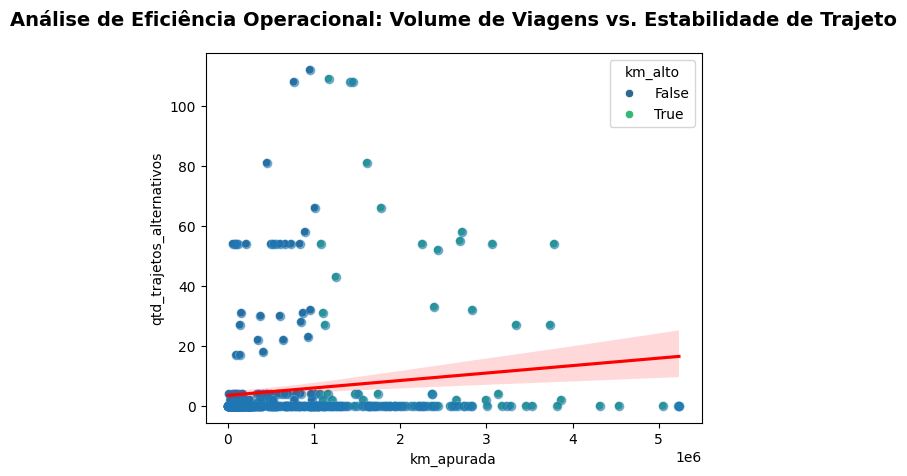

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# transformando os dados nas informações úteis

# resumo da quilometragem
df_balanco_agrupado = df_balanco.groupby('servico')['km_apurada'].sum().reset_index()
## junta as linhas do mesmo serviço de onibus e soma os valores da coluna, tendo o total pra cada linha de onibus

df_trajeto_contagem = df_trajeto.groupby('servico').size().reset_index(name='qtd_trajetos_alternativos')
## conta quantas vezes cada linha de onibus aparece no arquivo com os trajetos alternativos

# cruzando os dados:
df_analise = pd.merge(df_balanco_agrupado, df_trajeto_contagem, on='servico', how='left').fillna(0)
## cola a lista com a quilometragem do lado da lista de contagem de problemas, incluindo as linhas que nao tiveram problemas
## se uma linha nao tiver aparecido no arquivo de problemas, preenche com "0"

# definição do que é o km alto
limite_km_alto = df_analise['km_apurada'].quantile(0.75)
## pyhton separa a lista das linhas e faz um corte na quantidade de km em 75%, então, as que tiverem rodado mais, serão marcadas
## faz coluna com "TRUE" ou "FALSE" pra facilitar na hora de colorir

df_analise['km_alto'] = df_analise['km_apurada'] > limite_km_alto

# calculo da correlçaão e construção do gráfico
correlacao = df_analise['km_apurada'].corr(df_analise['qtd_trajetos_alternativos'])
## utiliza o coeficiente de Pearson: se o resultado for perto de 1, a teoria de +KM = +problema confere.
## se estiver perto de 0, a maior quilometragem não teve influência significativa nos problemas (trajeto alternativo)

# gráfico de pontos
sns.scatterplot(data=df_analise, x='km_apurada', y='qtd_trajetos_alternativos', hue='km_alto', palette='viridis')
sns.regplot(data=df_analise, x='km_apurada', y='qtd_trajetos_alternativos', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
## linha vermelha de tendencia

plt.title('Análise de Eficiência Operacional: Volume de Viagens vs. Estabilidade de Trajeto', 
          fontsize=14, 
          fontweight='bold', 
          pad=20)

top_10_problemas = df_analise.sort_values(by='km_apurada', ascending=False).head(10)
## organiza uma tabela com as 10 linhas que mais rodaram
print(top_10_problemas)


#### Gráfico Análise de Eficiência Operacional: Volume de Viagens vs. Estabilidade de Trajeto

Eixo x : Quilometragem total apurada. Quanto mais à direito o ponto está, mais a linha deônibus rodou

Eixo y : Quantidade de trajetos alternativos. Quanto mais para cima o ponto está, mais desvios de rota a linha de ônibus teve.

As bolinhas azuis foram as que não tiveram uma contagem de km considerada alta, enquanto as verdes foram as que tiveram.

Linha vermelha: Linha de tendência. Mostra que existe sim uma relação de quanto mais km rodados, maior é a probabilidade de desvios, porém, ao mesmo tempo, ela não é muito inclinada. Isso representa que essa relação não é muito significativa. 
A sombra representa a margem de erro dessa tendência.

#### Gráfico

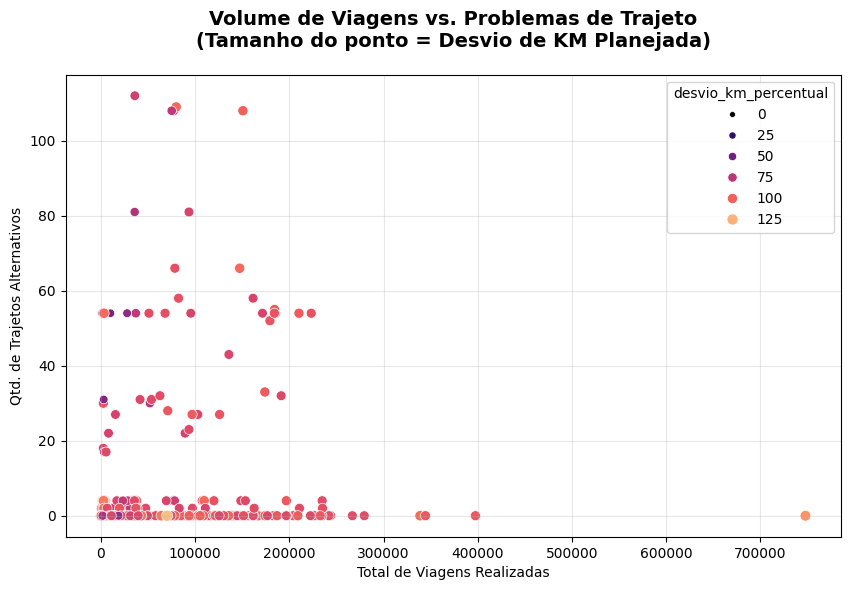

Análise de Eficiência (Top 10 linhas com maior desvio de KM Planejada):
    servico  viagens  desvio_km_percentual  qtd_trajetos_alt
443   SN825     1275            149.969874               0.0
452   SN880     2499            144.005068               0.0
448   SN861     1879            138.183489               0.0
426   SN600     1551            135.520140               0.0
489   SP852    70302            129.356392               0.0
424   SN554     1616            126.895291               0.0
374  LECD89      647            124.747242               0.0
3       012     3499            123.735396               0.0
357  LECD72    13236            119.507973               0.0
409   SN388     1506            118.852339               0.0


In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# calcular a acurácia do trajeto ( se km apurada foi muito maior que a planejada, gastando mais)
df_hist_agrupado['desvio_km_percentual'] = (df_hist_agrupado['km_apurada'] / df_hist_agrupado['km_planejada']) * 100
df_hist_agrupado['km_por_viagem'] = df_hist_agrupado['km_apurada'] / df_hist_agrupado['viagens']

# relaciona com a quantidade de problemas
df_trajeto_contagem = df_trajeto.groupby('servico').size().reset_index(name='qtd_trajetos_alt')
df_analise_v2 = pd.merge(df_hist_agrupado, df_trajeto_contagem, on='servico', how='left').fillna(0)

# pra criar gráfico impacto na receita x desvios
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_analise_v2, x='viagens', y='qtd_trajetos_alt', size='desvio_km_percentual', hue='desvio_km_percentual', palette='magma')
plt.title('Volume de Viagens vs. Problemas de Trajeto\n(Tamanho do ponto = Desvio de KM Planejada)',
          fontsize=14, 
          fontweight='bold', 
          pad=20)
plt.xlabel('Total de Viagens Realizadas')
plt.ylabel('Qtd. de Trajetos Alternativos')
plt.grid(True, alpha=0.3)
plt.show()

# listar as linhas mais ineficientes, ou seja, mais km que o planejado
print("Análise de Eficiência (Top 10 linhas com maior desvio de KM Planejada):")
print(df_analise_v2.sort_values(by='desvio_km_percentual', ascending=False).head(10)[['servico', 'viagens', 'desvio_km_percentual', 'qtd_trajetos_alt']])

#### Gráfico volume de viagens vs problemas de trajeto:

Eixo x: Total de viagens. Quanto mais à direita um ponto está, mais vezes o ônibus da linha completou seu percurso.
Eixo y: Trajetos alternativos. Quanto mais alto um ponto está, mais a linha sai da sua rota original.

Bolas mais azul: representam as linhas mais comportadas, que rodam de acordo com seu planejamento.
Bolas mais rosa: as linhas mais ineficientes e caras, que rodam mais km que o planejado. 

## Conclusões:

Com o gráfico scatter plot, é possível definir se há alguma relação de causa e efeito entre a quilometragem e os problemas no trajeto.


O gráfico explicita que a teoria de que +KM = +problemas não é totalmente verdade! Em resumo, muitas das linhas de ônibus que rodam muito são, na verdade, bem estáveis.

-------
Novas conclusões, após analisar também o número de viagens de cada linha:

O volume de viagens e a quilometragem percorrida não são os principais problemas, mas sim a ineficiência do trajeto (Desvio de KM Planejada).

Com apenas as informções anteriores, queríamos provar que as linhas com mais quilometragem poderiam ser as problemáticas, mas, na verdade, as linhas com uma quilometragem apurada muito maior que a planejada que são.

Linhas com esses "trajetos alternativos" têm um desvio percentual de km maior, fazendo com que a empresa gaste mais combustível em quilômetros que nem era planejados e, por sua vez, não geram receita tarifária extra ou até bônus de subsídio (já que não existe uma estratégia por trás deles).

Em algumas linhas, inclusive (por exemplo 435 e 623), o subsídio é pago com base no desempenho planejado, mas esses desvios causam um consumo desnecessário do lucro.

Enfim, a relação entre volume de viagens e problemas em si é baixa, porém, o mal reside nas linhas onde o km apurado é muito superior ao km planejado, o que causa um desperdício dos recursos operacionais sem o devido retorno em subsídio ou receita tarifária.
